# <center>Data-Driven Strategies for Global Expansion: Maximizing Content Relevance and Growth Opportunities for Netflix</center>


In [148]:
# importing necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

- Loading the dataset 

In [149]:
df = pd.read_csv("original_netflix.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Un-nesting the Cast Columns 
In the provided dataset, the **cast column** contains all the names of actors nested within a single cell. To extract these names and create a new column called **actors**, we will separate each actor's name into its own row.

After un-nesting the actors' names, we will drop the cast column since we will have the individual actor names distributed across multiple rows.

In [151]:
df["actors"] = df["cast"].str.split(",")
df = df.explode("actors")
df.drop("cast", axis = 1, inplace=True)
df.reset_index(drop = True, inplace = True)

df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,description,actors
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Ama Qamata
2,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Khosi Ngema
3,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Gail Mabalane
4,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Thabang Molaba
...,...,...,...,...,...,...,...,...,...,...,...,...
64946,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Manish Chaudhary
64947,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Meghna Malik
64948,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Malkeet Rauni
64949,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Anita Shabdish


# Un-nesting the listed_in Columns

Similar to un-nesting the Cast column we also do the same for listed_in Columns and creat a new column called **genre**

In [152]:
df["genre"] = df["listed_in"].str.split(",")
df = df.explode("genre")
df.drop("listed_in", axis = 1, inplace=True)
df.reset_index(drop = True, inplace = True)

df

,show_id,type,title,director,country,date_added,release_year,rating,duration,description,actors,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,"As her father nears the end of his life, filmm...",NaN,Documentaries
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,International TV Shows
2,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Dramas
3,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Mysteries
4,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...
149507,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,International Movies
149508,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,Music & Musicals
149509,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,Dramas
149510,s8807,Movie,Zubaan,Mozez Singh,India,"March 2, 2019",2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,International Movies


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149512 entries, 0 to 149511
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   show_id       149512 non-null  object
 1   type          149512 non-null  object
 2   title         149512 non-null  object
 3   director      104891 non-null  object
 4   country       138367 non-null  object
 5   date_added    149354 non-null  object
 6   release_year  149512 non-null  int64 
 7   rating        149445 non-null  object
 8   duration      149509 non-null  object
 9   description   149512 non-null  object
 10  actors        148008 non-null  object
 11  genre         149512 non-null  object
dtypes: int64(1), object(11)
memory usage: 13.7+ MB


# Converting date_added Column to datetime object for extraction of month and 
# Creation of bins for week

In [154]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce') # Convert the 'date_added' column to datetime format, handling errors and removing leading spaces
df = df.dropna(subset=['date_added'])
df['month_added'] = df['date_added'].dt.strftime('%B')

C:\Users\Vijaykumar\AppData\Local\Temp\ipykernel_548\1377758484.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_added'] = df['date_added'].dt.strftime('%B')


In [155]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,description,actors,genre,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,"As her father nears the end of his life, filmm...",NaN,Documentaries,September
1,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,International TV Shows,September
2,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Dramas,September
3,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Mysteries,September
4,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Khosi Ngema,International TV Shows,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149507,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,International Movies,March
149508,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,Music & Musicals,March
149509,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,Dramas,March
149510,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,International Movies,March


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148047 entries, 0 to 149511
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   show_id       148047 non-null  object        
 1   type          148047 non-null  object        
 2   title         148047 non-null  object        
 3   director      104825 non-null  object        
 4   country       136914 non-null  object        
 5   date_added    148047 non-null  datetime64[ns]
 6   release_year  148047 non-null  int64         
 7   rating        147980 non-null  object        
 8   duration      148044 non-null  object        
 9   description   148047 non-null  object        
 10  actors        146555 non-null  object        
 11  genre         148047 non-null  object        
 12  month_added   148047 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 15.8+ MB


### the week bins are as follows

- 1st week 
- 2nd week
- 3rd week 
- 4th week

- if day is between 1 to 7  then 1st week
- if day is between 7 to 14  then 2nd week
- if day is between 15 to 21  then 3rd week
- if day is between 22 to 31  then 4th week

In [157]:
df['day_of_month'] = df['date_added'].dt.day

bins = [0, 7, 14, 21, 32]
labels = ['1st week', '2nd week', '3rd week', '4th week']

df['released_week'] = pd.cut(df['day_of_month'], bins=bins, labels=labels, right=False)

df = df.drop(columns=['day_of_month'])


C:\Users\Vijaykumar\AppData\Local\Temp\ipykernel_548\2540191002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_of_month'] = df['date_added'].dt.day
C:\Users\Vijaykumar\AppData\Local\Temp\ipykernel_548\2540191002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['released_week'] = pd.cut(df['day_of_month'], bins=bins, labels=labels, right=False)


In [158]:
df


,show_id,type,title,director,country,date_added,release_year,rating,duration,description,actors,genre,month_added,released_week
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,"As her father nears the end of his life, filmm...",NaN,Documentaries,September,4th week
1,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,International TV Shows,September,4th week
2,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Dramas,September,4th week
3,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Mysteries,September,4th week
4,s2,TV Show,Blood & Water,NaN,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Khosi Ngema,International TV Shows,September,4th week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149507,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,International Movies,March,1st week
149508,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,Music & Musicals,March,1st week
149509,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,Dramas,March,1st week
149510,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,International Movies,March,1st week


# Handling null values

In [159]:
# no of missing values in every column
df.isnull().sum(axis = 0)

show_id              0
type                 0
title                0
director         43222
country          11133
date_added           0
release_year         0
rating              67
duration             3
description          0
actors            1492
genre                0
month_added          0
released_week        0
dtype: int64

In [235]:
df["director"] = df["director"].fillna("Unknown_director")
df["country"] = df["country"].fillna("Unknown_country")
df["rating"] = df["rating"].fillna("Unknown_rating")
df.dropna(subset=['duration'], inplace = True)
df["actors"] = df["actors"].fillna("Unknown_actor")

df

,show_id,type,title,director,country,date_added,release_year,rating,duration,description,actors,genre,month_added,released_week
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,"As her father nears the end of his life, filmm...",Unknown_actor,Documentaries,September,4th week
1,s2,TV Show,Blood & Water,Unknown_director,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,International TV Shows,September,4th week
2,s2,TV Show,Blood & Water,Unknown_director,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Dramas,September,4th week
3,s2,TV Show,Blood & Water,Unknown_director,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Ama Qamata,TV Mysteries,September,4th week
4,s2,TV Show,Blood & Water,Unknown_director,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",Khosi Ngema,International TV Shows,September,4th week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149507,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,International Movies,March,1st week
149508,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Anita Shabdish,Music & Musicals,March,1st week
149509,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,Dramas,March,1st week
149510,s8807,Movie,Zubaan,Mozez Singh,India,2019-03-02,2015,TV-14,111 min,A scrappy but poor boy worms his way into a ty...,Chittaranjan Tripathy,International Movies,March,1st week


In [161]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
country          0
date_added       0
release_year     0
rating           0
duration         0
description      0
actors           0
genre            0
month_added      0
released_week    0
dtype: int64

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148044 entries, 0 to 149511
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   show_id        148044 non-null  object        
 1   type           148044 non-null  object        
 2   title          148044 non-null  object        
 3   director       148044 non-null  object        
 4   country        148044 non-null  object        
 5   date_added     148044 non-null  datetime64[ns]
 6   release_year   148044 non-null  int64         
 7   rating         148044 non-null  object        
 8   duration       148044 non-null  object        
 9   description    148044 non-null  object        
 10  actors         148044 non-null  object        
 11  genre          148044 non-null  object        
 12  month_added    148044 non-null  object        
 13  released_week  148044 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(1), object(11)
m

# <center>1. Find the counts of each categorical variable both using graphical and non-graphical analysis.</center>


In [218]:
df1 = pd.read_csv("original_netflix.csv")

### Number of Movies and TV series

In [220]:
df1["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

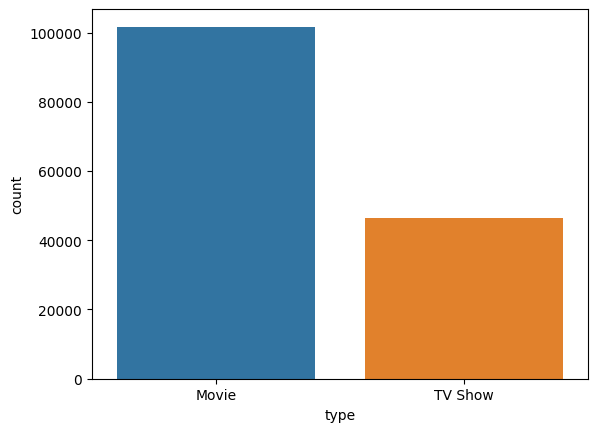

In [221]:
sns.countplot(data = df, x = "type")

- There are total 6131 movies and 2676 TV Shows in the dataset

In [230]:
df["director"].nunique()

4524

- There are total 4524 director in the given data set

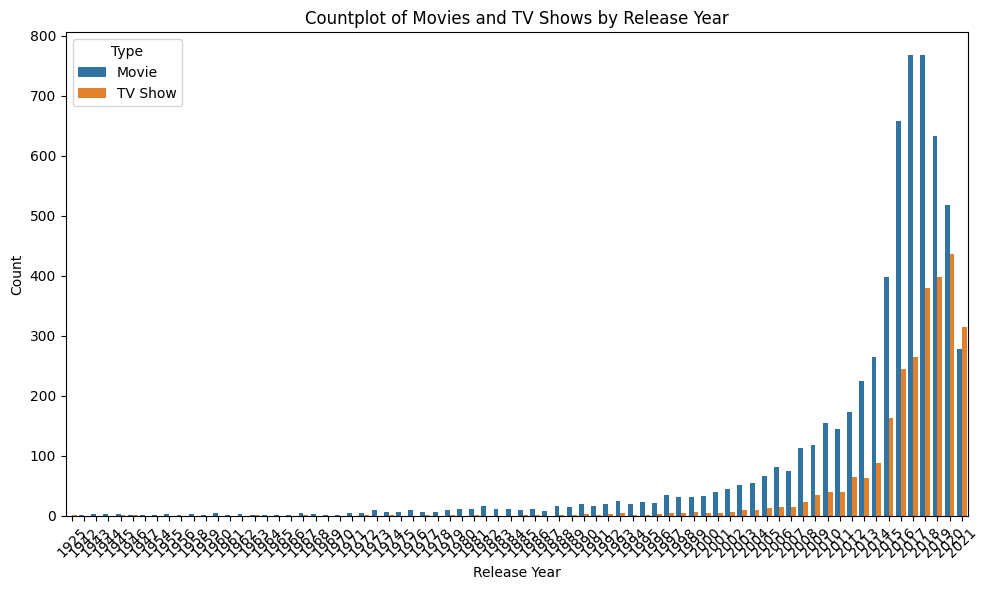

In [239]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df1, x='release_year', hue='type')
plt.xticks(rotation=45)
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Countplot of Movies and TV Shows by Release Year')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

# Actionable insights

From the above chart our platform has a higher number of movies compared to TV shows and that there was a period of rapid growth in the number of movies and TV shows from 2014 to 2017 followed by a dip after 2018, several conclusions and insights can be drawn:

1. **Content Strategy Evolution:**
   - The rapid increase in the number of movies and TV shows from 2014 to 2017 suggests that we was aggressively expanding its content library to attract and retain subscribers during that period.
   - The subsequent dip in content growth after 2018 could indicate a shift in content strategy or a more selective approach to producing new content.

2. **Market Saturation:**
   - The dip in content growth after 2018 might suggest that our's content library reached a certain level of saturation, where adding more content may have diminishing returns.
   - The decrease in growth could also be a result of increased competition from other streaming platforms entering the market.

3. **Focus on Quality:**
   - The decline in content growth after 2018 could indicate that we started prioritizing quality over quantity, aiming to produce higher-caliber shows and movies that resonate with audiences.
   - The decrease in content growth might also reflect efforts to invest in original, critically acclaimed content rather than simply increasing the number of titles.

4. **Changing Viewer Preferences:**
   - Viewer preferences might have shifted after 2018, leading to changes in the types of content they are seeking. This could influence our decision to produce more of certain types of shows or movies.

5. **Platform Maturity:**
   - As the streaming landscape matures, streaming platforms like Netflix may focus on optimizing their existing content library and enhancing user experience rather than solely expanding the number of titles.

6. **Production Challenges:**
   - The dip in content growth could be due to production challenges such as disruptions caused by global events (e.g., pandemic-related disruptions) or logistical issues.

7. **Market Insights:**
   - Netflix might be relying on data and insights from user behavior to guide content decisions, leading to a more targeted and strategic approach to content creation.

8. **Diversification and Innovation:**
   - We could be exploring other forms of content innovation, such as interactive shows, documentaries, limited series, and collaborations with renowned creators.

9. **Global Expansion:**
   - The changes in content growth rates could be related to Netflix's efforts to expand its global footprint, focusing on producing localized and culturally relevant content in different regions.

In conclusion, the data suggests that we has gone through phases of aggressive content expansion followed by a more focused and strategic approach. The dip in content growth after 2018 may indicate a shift in priorities, possibly towards higher-quality, innovative, and targeted content to meet changing viewer preferences and navigate a competitive streaming landscape.

# <center> Comparison of Tv shows vs. Movies </center>

## To Find the number of movies produced in each country and pick the top 10 countries.

In [247]:
movies_df = df1[df1['type'] == 'Movie']

movie_counts_by_country = movies_df.groupby('country')['title'].nunique()

top_10_countries = movie_counts_by_country.nlargest(10)

print(top_10_countries)


country
United States     2058
India              893
United Kingdom     206
Canada             122
Spain               97
Egypt               92
Nigeria             86
Indonesia           77
Japan               76
Turkey              76
Name: title, dtype: int64


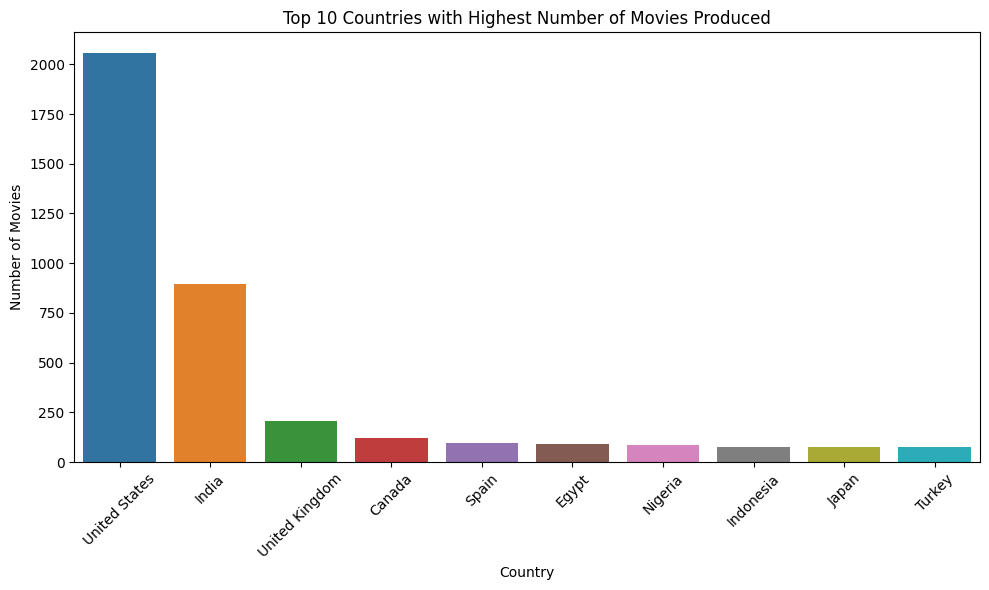

In [246]:
movies_df = df1[df1['type'] == 'Movie']

movie_counts_by_country = movies_df.groupby('country')['title'].nunique()

top_10_countries = movie_counts_by_country.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values)
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.title('Top 10 Countries with Highest Number of Movies Produced')
plt.tight_layout()
plt.show()


## Finding the number of TV-Shows produced in each country and pick the top 10 countries.

In [248]:
tv_df = df1[df1['type'] == 'TV Show']

tv_counts_by_country = tv_df.groupby('country')['title'].nunique()

top_10_countries = tv_counts_by_country.nlargest(10)

print(top_10_countries)

country
United States     760
United Kingdom    213
Japan             169
South Korea       158
India              79
Taiwan             68
Canada             59
France             49
Australia          48
Spain              48
Name: title, dtype: int64


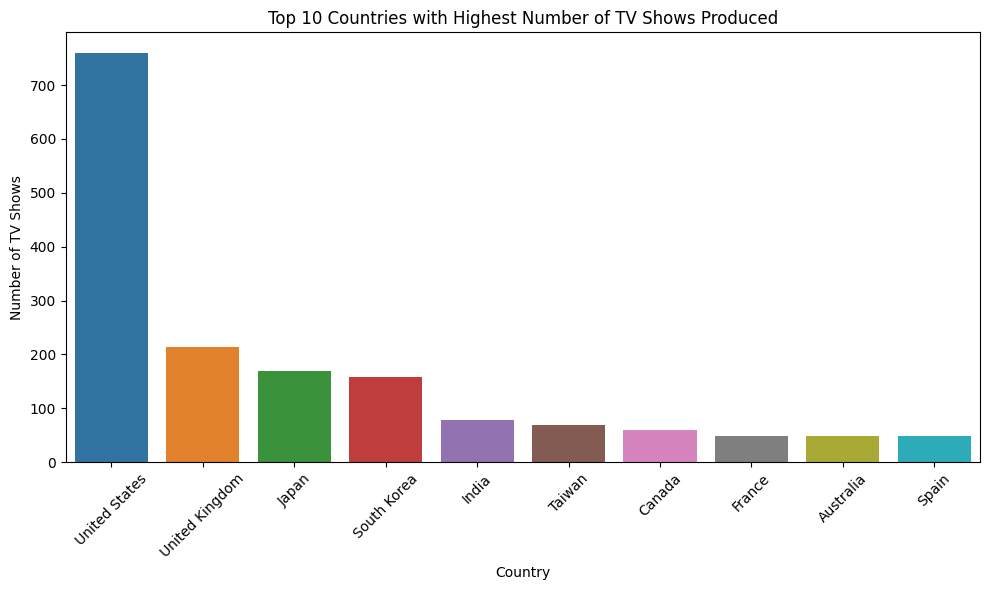

In [250]:
tv_df = df1[df1['type'] == 'TV Show']

tv_counts_by_country = tv_df.groupby('country')['title'].nunique()

top_10_countries = tv_counts_by_country.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values)
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')
plt.title('Top 10 Countries with Highest Number of TV Shows Produced')
plt.tight_layout()
plt.show()

### <center> Based on my analysis of the top countries with the highest number of movies and TV shows produced, here are some actionable insights.</center>
1. **Content Localization:**
   - Given the prominence of local content in India, consider producing more content tailored to Indian audiences, including original series and movies that reflect local culture, languages, and preferences.
   - For countries like Spain, Egypt, Nigeria, and Indonesia, focus on creating content that resonates with the local audience, emphasizing cultural authenticity and relatability.

2. **Global Blockbusters:**
   - Leverage the United States' dominance in movie production to create and promote global blockbuster movies that appeal to a wide international audience.
   - Consider investing in big-budget productions that have the potential to become worldwide phenomena.

3. **Genre Diversification:**
   - Diversify content genres based on regional preferences. For example, in South Korea and Japan, where TV shows are popular, explore genres such as K-dramas and anime to cater to local fanbases.

4. **Cross-Cultural Collaborations:**
   - Foster cross-cultural collaborations between countries. For instance, collaborations between the United States and India, or Japan and South Korea, could create unique content that appeals to audiences in multiple regions.

5. **Localized Marketing Campaigns:**
   - Tailor marketing campaigns to specific countries and regions, highlighting content that is popular and culturally relevant. Use local influencers and trends to boost engagement.

6. **Partnerships with Local Creators:**
   - Collaborate with local content creators, directors, and talent to produce unique and innovative content that resonates with local audiences.

7. **Localized Subtitles and Dubbing:**
   - Improve user experience by providing accurate and high-quality subtitles and dubbing in the languages spoken in the top countries. This can enhance accessibility and viewer engagement.

8. **Originality and Diversity:**
   - Continue investing in original content that stands out and offers unique storytelling. Consider exploring diverse narratives and themes that can attract global attention.


9. **International Partnerships:**
    - Strengthen partnerships with local studios, production companies, and content distributors in key countries to co-produce and distribute content effectively.


10. **Global Events and Festivals:**
    - Participate in international film festivals and cultural events to showcase original content and create buzz in different countries.

11. **Regional Originals:**
    - Expand the production of regional original content beyond the top 10 countries to tap into emerging markets and diverse audiences.

12. **Quality Control and Brand Reputation:**
    - Focus on maintaining a consistent standard of quality for both movies and TV shows to uphold Netflix's brand reputation worldwide.

By applying these insights, Netflix can strategically produce and promote content that resonates with different audiences, enhance user engagement, and drive business growth across various countries.

# What is the best time to launch a TV show?

## Finding which is the best week to release the Tv-show or the movie

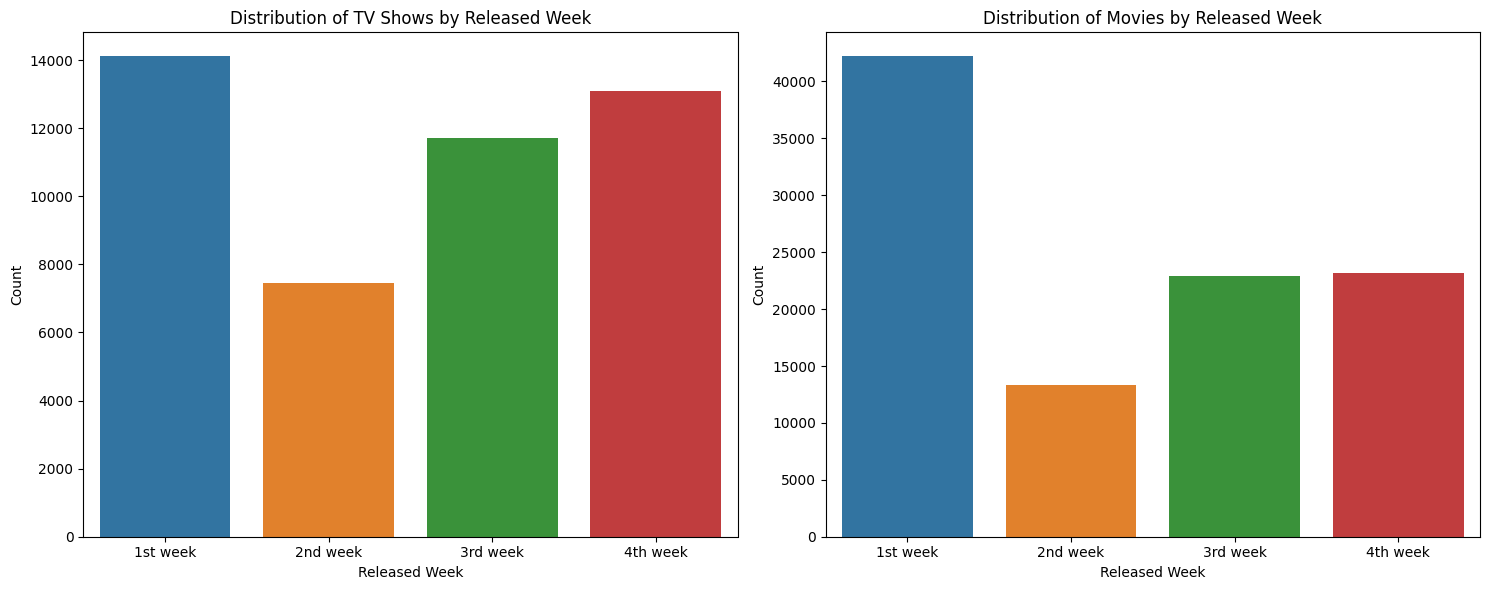

In [259]:
# Filter the DataFrame for TV shows and movies
tv_shows_df = df[df['type'] == 'TV Show']
movies_df = df[df['type'] == 'Movie']

# Create two separate countplots for TV shows and movies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Countplot for TV shows
sns.countplot(data=tv_shows_df, x='released_week', ax=ax1)
ax1.set_xlabel('Released Week')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of TV Shows by Released Week')

# Countplot for movies
sns.countplot(data=movies_df, x='released_week', ax=ax2)
ax2.set_xlabel('Released Week')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Movies by Released Week')

plt.tight_layout()
plt.show()


# Finding which is the best Month to release the Tv-show or the movie

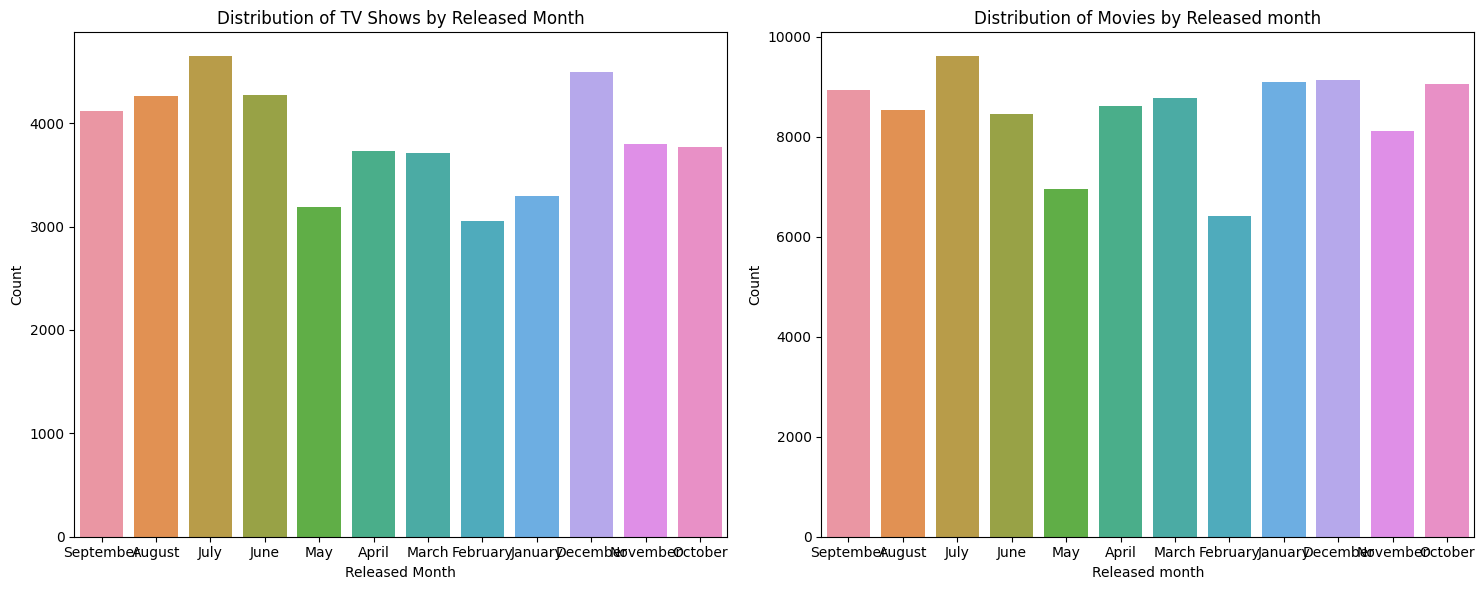

In [257]:
# Filter the DataFrame for TV shows and movies
tv_shows_df = df[df['type'] == 'TV Show']
movies_df = df[df['type'] == 'Movie']


# Create two separate countplots for TV shows and movies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Countplot for TV shows
sns.countplot(data=tv_shows_df, x='month_added', ax=ax1)
ax1.set_xlabel('Released Month')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of TV Shows by Released Month')

# Countplot for movies
sns.countplot(data=movies_df, x='month_added', ax=ax2)
ax2.set_xlabel('Released month')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Movies by Released month')

plt.tight_layout()
plt.show()

Based on the above insights about the best weeks and months for movie and TV show releases, along with the worst-performing ones, we can derive some actionable insights for Netflix to potentially help grow its business:

1. **Strategic Release Timing:**
   - Focus on releasing new content during the 1st week of each month for both movies and TV shows. This aligns with the preferred release weeks for both types of content and can attract more viewership during these periods.
   - Consider reserving high-profile releases for the best-performing months of July, December, and January. These months have shown a higher likelihood of success in terms of audience engagement.

2. **Optimized Content Scheduling:**
   - Allocate more resources and marketing efforts to ensure a strong lineup of releases during the best-performing months and weeks. This can maximize viewership and capitalize on periods of higher demand.

3. **Content Diversity:**
   - Analyze the genres and themes of the most successful releases during the best-performing months. Identify patterns in audience preferences and tailor content to align with these trends.
   - Diversify content offerings to appeal to different audience segments, potentially exploring new genres or storylines that have performed well during the identified peak months.

4. **Strategic Marketing Campaigns:**
   - Plan robust marketing and promotional campaigns around releases during the 1st week of the month for both movies and TV shows. Highlight these releases as special events to attract more attention and subscribers.

5. **Addressing Low-Performing Months:**
   - Investigate the reasons behind the underperformance of certain months (e.g., February and May) for both movies and TV shows. Consider experimenting with different release strategies or exclusive content offerings to mitigate this trend.

6. **Audience Engagement:**
   - Leverage user data and viewer preferences to personalize content recommendations during the 1st week of the month, encouraging higher engagement and retention.

7. **Viewer Surveys and Feedback:**
   - Collect feedback from subscribers about their preferences for release timing and content selection. Use this information to fine-tune the release strategy and content library.

8. **Global Release Strategy:**
   - Consider applying the insights gained from the preferred release weeks and months to a global release strategy. Tailor content releases for different regions based on their preferences and cultural events.

9. **Collaborations and Partnerships:**
   - Collaborate with popular creators, directors, or actors known to attract audiences during the best-performing weeks and months. Leverage their influence to enhance the visibility and success of new releases.

# Analysis of actors/directors of different types of shows/movies.

## 1. Top 10 actors who have appeared in most Movies

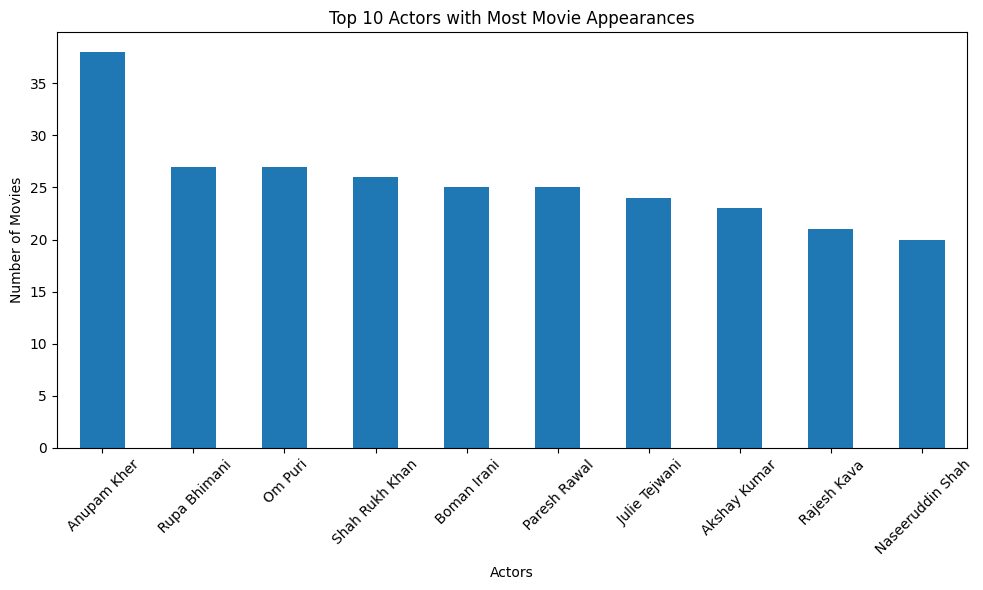

In [263]:
df2 = pd.read_csv("original_netflix.csv")

df2["actors"] = df2["cast"].str.split(",")
df2 = df2.explode("actors")
df2.drop("cast", axis = 1, inplace=True)
df2.reset_index(drop = True, inplace = True)



movie_df2 = df2[df2['type'] == 'Movie']

# Group by actor and count unique titles
actor_counts = movie_df2.groupby('actors')['title'].nunique()

# Sort the actors by count in descending order and get top 10
top_actors = actor_counts.sort_values(ascending=False).head(10)

# Plot a bar chart
plt.figure(figsize=(10, 6))
top_actors.plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Number of Movies')
plt.title('Top 10 Actors with Most Movie Appearances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top 10 actors who have appeared in most TV Series

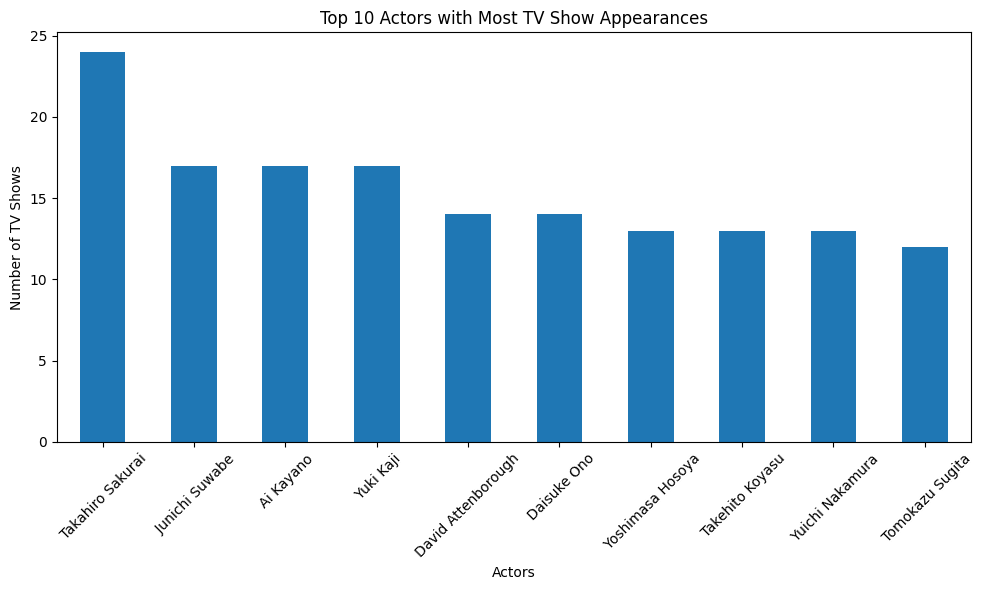

In [264]:
TV_show_df2 = df2[df2['type'] == 'TV Show']

# Group by actor and count unique titles
actor_counts = TV_show_df2.groupby('actors')['title'].nunique()

# Sort the actors by count in descending order and get top 10
top_actors = actor_counts.sort_values(ascending=False).head(10)

# Plot a bar chart
plt.figure(figsize=(10, 6))
top_actors.plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Number of TV Shows')
plt.title('Top 10 Actors with Most TV Show Appearances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Top 10 Directors who have appeared in most Movies

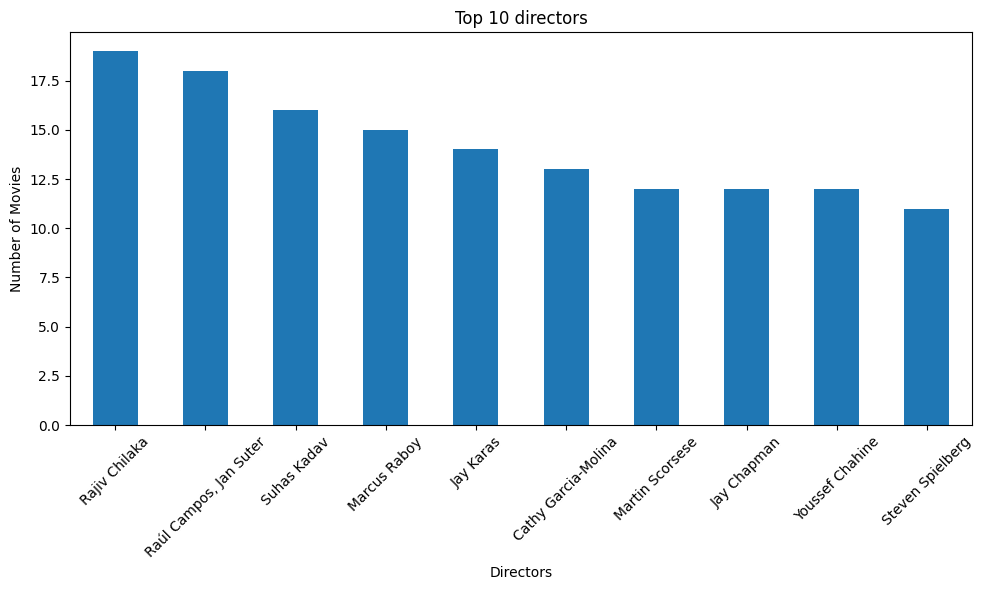

In [267]:
movie_df1 = df1[df1['type'] == 'Movie']

# Group by actor and count unique titles
director_counts = movie_df1.groupby('director')['title'].nunique()

# Sort the actors by count in descending order and get top 10
top_director = director_counts.sort_values(ascending=False).head(10)

# Plot a bar chart
plt.figure(figsize=(10, 6))
top_director.plot(kind='bar')
plt.xlabel('Directors')
plt.ylabel('Number of Movies')
plt.title('Top 10 directors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Top 10 Directors who have appeared in most TV Shows

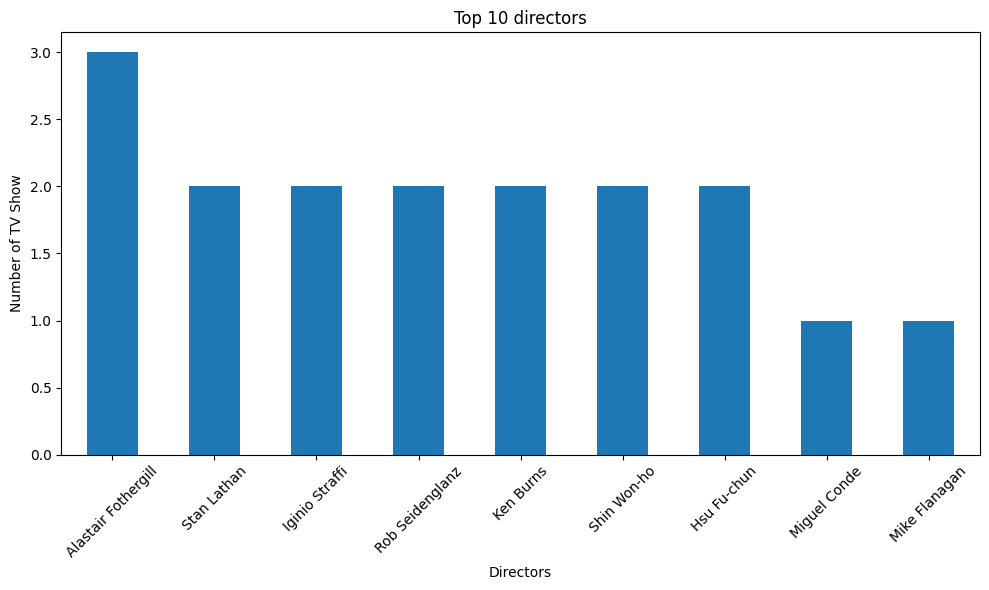

In [269]:
TV_Show_df1 = df1[df1['type'] == 'TV Show']

# Group by actor and count unique titles
director_counts = TV_Show_df1.groupby('director')['title'].nunique()

# Sort the actors by count in descending order and get top 10
top_director = director_counts.sort_values(ascending=False).head(9)

# Plot a bar chart
plt.figure(figsize=(10, 6))
top_director.plot(kind='bar')
plt.xlabel('Directors')
plt.ylabel('Number of TV Show')
plt.title('Top 10 directors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Actionable insights 
Based on the Above data about the top actors and directors who have appeared in the most movies and TV shows, here are some actionable insights:

**For Actors:**

1. **Actor Collaborations:** Leverage the popularity of actors such as Anupam Kher, Rupa Bhimani, and Shah Rukh Khan to attract a wider audience. Consider featuring them in exclusive content, new releases, or original productions to draw in their dedicated fan bases.

2. **Diverse Content:** Understand the genres and themes that these top actors are associated with and create a diverse range of content to appeal to different audience segments. Offer a mix of genres that align with their strengths and preferences.

3. **Exclusive Deals:** Consider offering exclusive contracts or partnerships with these top actors to produce unique and high-quality content. Exclusive releases featuring these actors can encourage new subscriptions and retain existing subscribers.

4. **Cross-Promotions:** Collaborate with these top actors for promotional activities, interviews, or special events that can create buzz and increase engagement among subscribers.

**For Directors:**

1. **Directorial Vision:** Partner with the top directors, such as Rajiv Chilaka and Iginio Straffi, to bring their creative visions to the streaming platform. Highlight their unique storytelling styles and build curated collections of their work to attract cinephiles.

2. **Original Productions:** Collaborate with these top directors to produce exclusive original content, including movies and TV shows, that showcase their expertise. Original content can set Netflix apart and draw in subscribers seeking fresh and innovative storytelling.

3. **Global Appeal:** If the directors have a global following, consider expanding the availability of their work to different regions, taking advantage of their international appeal to attract diverse audiences.

4. **Director Spotlight:** Create a dedicated section on the platform that showcases the works of these top directors. This can help viewers discover their filmography and engage with their content.

5. **Directorial Diversity:** While focusing on top directors is important, also explore opportunities to work with emerging and diverse directors. Diversifying the directorial lineup can bring fresh perspectives and attract a broader audience.

6. **Audience Engagement:** Leverage the influence of top directors to engage with subscribers through interviews, behind-the-scenes content, and interactive experiences related to their works.

7. **Film Festivals and Awards:** Consider participating in film festivals and awards where the works of these directors are featured. This can generate buzz, recognition, and potential awards for Netflix's original content.


# Which genre movies are more popular or produced more ?

In [ ]:
Which genre movies are more popular or produced more ?

Hint : We want you to apply the word cloud on the genre columns to know which kind
of genre is produced

I have column name "title" which have the names of the movies
I have column name "type" which have "Movies" and "TV Show"
I have column name "genre" which have genre of movies

plot a chart in seaborn answering this question


In [274]:
from wordcloud import WordCloud

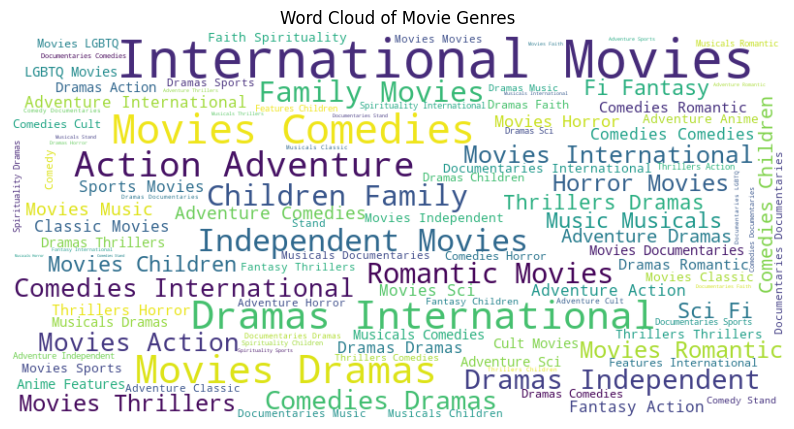

In [276]:
from wordcloud import WordCloud

movie_df = df[df['type'] == 'Movie']

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(movie_df['genre']))

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Genres')
plt.show()

## actionable insights 

Based on the insights from the word cloud analysis of movie genres and the observation that certain genres are produced on a larger scale while others are produced on a smaller scale, here are some actionable insights 

**1. Leveraging Popular Genres:**

   - **Invest in High-Popularity Genres:** Given the large production scale of genres like International Movies, Drama, Comedy, Action Adventure, and Horror, consider allocating resources to create and acquire more content in these genres. Audiences are more likely to engage with content that aligns with popular preferences.

   - **Exclusive Content:** Focus on securing exclusive deals for highly popular genres. Exclusive content can attract subscribers who are specifically interested in those genres, providing a competitive advantage.

   - **Collaborations and Partnerships:** Collaborate with renowned directors, producers, and actors within these popular genres to create compelling and high-quality content that can draw in a larger audience.

**2. Niche Content Strategy:**

   - **Target Niche Audiences:** While genres like LGBTQ Movies, Faith Spirituality, Musical Romantics, Features Children, and Documentary Sports may be produced on a smaller scale, they cater to niche audiences with dedicated interests. Create a strategy to appeal to these specific segments by offering curated content, collections, and recommendations.

   - **Unique Originals:** Consider producing original content in these smaller-scale genres. Unique and well-crafted originals can help Netflix stand out in the market and attract subscribers who have a passion for these genres.

**3. Data-Driven Personalization:**

   - **Enhanced Recommendation Algorithms:** Leverage user data and viewing history to improve the recommendation algorithms. Tailor content suggestions to match the preferences of individual subscribers, including both popular genres and niche interests.

   - **User Surveys and Feedback:** Gather feedback from subscribers about their genre preferences and interests. Use this information to fine-tune the content library and production strategy.

**4. Strategic Marketing:**

   - **Highlight Diverse Content:** Showcase the wide range of genres available on Netflix through marketing campaigns. Emphasize both popular genres and niche content to attract a diverse subscriber base.

   - **Genre-Specific Campaigns:** Develop targeted marketing campaigns for specific genres, especially for smaller-scale genres. Highlight the unique and valuable aspects of these genres to attract relevant viewers.

**5. Collaboration and Partnerships:**

   - **Cultural and Regional Content:** For International Movies, explore collaborations with filmmakers from different countries to enhance the platform's global appeal. Tailor content offerings to cater to the cultural interests of various regions.

   - **Inclusivity and Representation:** Focus on LGBTQ Movies and other genres that promote inclusivity and diversity. Collaborate with creators who can bring authentic and representative storytelling to these genres.

**6. Diversified Content Strategy:**

   - **Balanced Portfolio:** Maintain a balance between producing content in popular genres and exploring smaller-scale genres. A diversified content strategy can attract a broader range of subscribers while catering to varied tastes.


# To  find After how many days the movie will be added to Netflix after the release of the movie

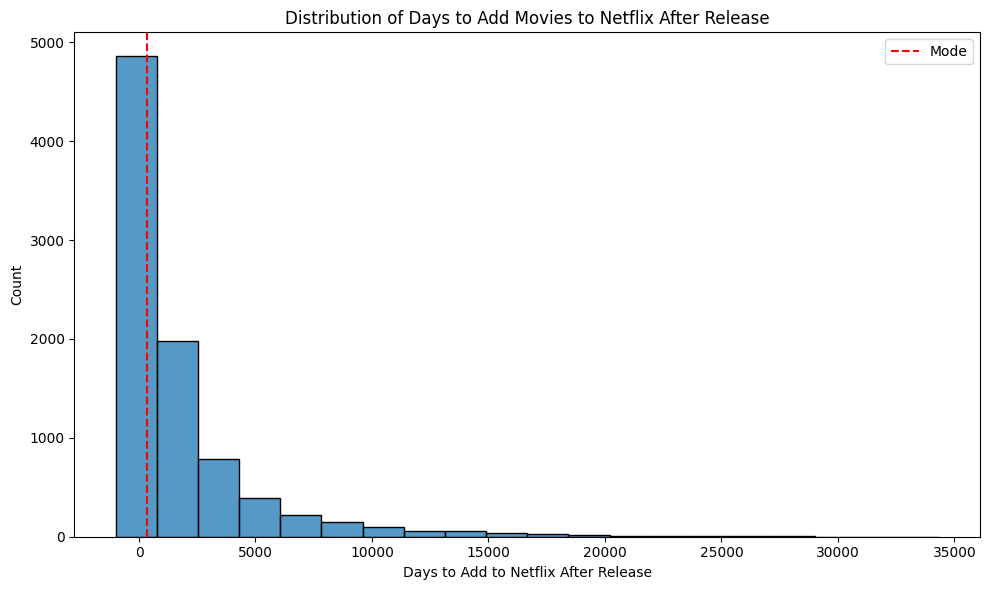

In [283]:

# Convert 'date_added' column to datetime
df1['date_added'] = pd.to_datetime(df1['date_added'])

# Calculate the difference between date_added and release_year
df1['days_to_add'] = (df1['date_added'] - pd.to_datetime(df1['release_year'], format='%Y')).dt.days

# Calculate the mode of the 'days_to_add' column
mode_days_to_add = df1['days_to_add'].mode()[0]

# Plot a histogram using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data=df1, x='days_to_add', bins=20)
plt.axvline(x=mode_days_to_add, color='red', linestyle='--', label='Mode')
plt.xlabel('Days to Add to Netflix After Release')
plt.ylabel('Count')
plt.title('Distribution of Days to Add Movies to Netflix After Release')
plt.legend()
plt.tight_layout()
plt.show()

# Overall insights form the above Case Study

1. Emerging Trends:

Stay attuned to emerging trends and changing audience preferences. Monitor shifts in viewer behavior and genre popularity to adapt the content strategy accordingly.

2. Experimentation:

Allocate resources for experimental content within popular genres to test new themes, formats, or storytelling approaches. This can help attract and engage viewers with fresh and innovative content.

3. Storytelling Innovation:

Explore innovative storytelling techniques, such as interactive narratives, virtual reality experiences, or multi-part series, to captivate and retain audiences in an evolving media landscape.

4. Localized Originals:

For regions with strong preferences for specific genres (e.g., Action in one country, Drama in another), create localized original content that resonates with local tastes while maintaining global appeal.

5. Diversity and Inclusivity:

Emphasize diversity and inclusivity within popular genres to attract a broader audience. Integrate diverse perspectives and representation into content to connect with underrepresented communities.

6. Data-Driven Decision-Making:

Leverage data analytics to continuously assess content performance, viewer engagement, and market trends. Make informed decisions about content production, acquisition, and promotion based on actionable insights.

7. Audience Interaction:

Engage with the audience through social media, surveys, and interactive campaigns to gauge preferences and gather feedback. Incorporate viewer suggestions and ideas into content creation.

8. Platform Features:

Innovate platform features that enhance the viewing experience. For example, offer curated playlists, genre-specific channels, or binge-watching recommendations based on individual preferences.

9. Cross-Promotions and Partnerships:

Collaborate with other brands, franchises, or creators to cross-promote content and tap into existing fan bases. Partnerships can help increase visibility and attract new subscribers.

10. Genre-Mixing:

Experiment with blending genres to create unique and captivating content that appeals to multiple interests. This can lead to innovative storytelling and broaden the audience base.

11. Tailored International Offerings:

For countries with specific genre preferences, consider tailoring the content library to match local tastes while also offering a diverse selection of international content.

12. User-Generated Content:

Integrate user-generated content, such as fan creations, reviews, or recommendations, into the platform. This can foster community engagement and enhance the overall viewing experience.

13. Transparency and Communication:

Maintain transparency with subscribers about content additions, updates, and upcoming releases. Effective communication can create anticipation and excitement around new releases.

14. Continuous Adaptation:

Regularly reassess the content strategy based on viewership patterns, market dynamics, and audience feedback. Flexibility and adaptability are key to sustaining growth in the dynamic streaming industry.

By implementing these insights, Netflix can navigate changing audience preferences, optimize content offerings, and continue to expand its global reach while catering to diverse viewer tastes and preferences.